In [13]:
import os
import pennylane as qml
from pennylane import numpy as np
import numpy as onp
import matplotlib.pyplot as plt
import pandas as pd

from qiskit import QuantumCircuit
from pennylane.templates import StronglyEntanglingLayers


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

In [15]:
n_ansatz_layers = 1
n_layers = 5
n_qubits = 5


In [16]:
dev_parallel = qml.device("default.qubit", wires=n_qubits)

def S(x):
    for w in range(n_qubits):
        qml.RY(x[w], wires=w)

def W(theta):
    for l in range(n_ansatz_layers):
        for w in range(n_qubits):
            qml.Rot(theta[l, w, 0], theta[l, w, 1], theta[l, w, 2], wires=w)

        for w in range(n_qubits - 1):
            qml.CNOT(wires=[w, w + 1])

        qml.CNOT(wires=[n_qubits - 1, 0])


@qml.qnode(dev_parallel, interface="torch")
def circuit_parallel(params, x):
    for l in range(n_layers):
        S(x)
        W(params[l])

    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [17]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.classical = nn.Sequential(
            nn.Linear(n_qubits, 1),
            nn.Tanh()
        ).double()

        self.q_params = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_ansatz_layers,
                n_qubits,
                3,
                dtype=torch.float64
            )
        )

    def forward(self, x_batch):
        q_outputs = []

        for x in x_batch:
            q_out = circuit_parallel(self.q_params, x)

            # q_out is a list of n_qubits scalar tensors
            q_out = torch.stack(q_out)

            q_outputs.append(q_out)

        # Shape: (batch_size, n_qubits)
        q_outputs = torch.stack(q_outputs)

        y_pred = self.classical(q_outputs)

        return y_pred.squeeze()

In [18]:
file_path = "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"
df = pd.read_csv(file_path)

In [19]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch

series = df.iloc[:, 4].values.reshape(-1, 1)

train_series = series[:434]
test_series = series[434:]

scaler = MinMaxScaler(feature_range=(-1, 1))

train_scaled = scaler.fit_transform(train_series)
test_scaled = scaler.transform(test_series)

In [20]:
def series_to_X_y(arr, window_size):
    X = []
    y = []

    for i in range(len(arr) - window_size):
        X.append(arr[i:i + window_size])
        y.append(arr[i + window_size])

    return np.array(X), np.array(y)

WS = n_qubits

X_all_train, y_all_train = series_to_X_y(train_scaled, WS)

X_train = X_all_train[:334]
y_train = y_all_train[:334]

X_val = X_all_train[334:]
y_val = y_all_train[334:]

X_test, y_test = series_to_X_y(test_scaled, WS)

In [21]:

X_train_torch = torch.tensor(np.pi * X_train.squeeze(-1), dtype=torch.float64)
y_train_torch = torch.tensor(y_train.squeeze(-1), dtype=torch.float64)

X_val_torch = torch.tensor(np.pi * X_val.squeeze(-1), dtype=torch.float64)
y_val_torch = torch.tensor(y_val.squeeze(-1), dtype=torch.float64)

X_test_torch = torch.tensor(np.pi * X_test.squeeze(-1), dtype=torch.float64)
y_test_torch = torch.tensor(y_test.squeeze(-1), dtype=torch.float64)

In [22]:
# =========================
# TRAIN SAME HYBRID MODEL ON X_train
# =========================

model = HybridModel()

optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_func = nn.MSELoss()

n_epochs = 200

train_losses = []
#val_losses = []

for epoch in range(n_epochs):
    model.train()

    optimizer.zero_grad()

    y_pred_train = model(X_train_torch)

    train_loss = loss_func(y_pred_train, y_train_torch)

    train_loss.backward()
    optimizer.step()

    train_losses.append(train_loss.item())

    # Validation loss
    """
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val_torch)
        val_loss = loss_func(y_pred_val, y_val_torch)
        val_losses.append(val_loss.item())
    """

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss = {train_loss.item():.6f} | "
            
        )

Epoch 000 | Train Loss = 0.487543 | 
Epoch 005 | Train Loss = 0.417016 | 
Epoch 010 | Train Loss = 0.355226 | 
Epoch 015 | Train Loss = 0.305469 | 
Epoch 020 | Train Loss = 0.265958 | 
Epoch 025 | Train Loss = 0.233849 | 
Epoch 030 | Train Loss = 0.207507 | 
Epoch 035 | Train Loss = 0.186399 | 
Epoch 040 | Train Loss = 0.169655 | 
Epoch 045 | Train Loss = 0.156395 | 
Epoch 050 | Train Loss = 0.146460 | 
Epoch 055 | Train Loss = 0.139029 | 
Epoch 060 | Train Loss = 0.132773 | 
Epoch 065 | Train Loss = 0.128074 | 
Epoch 070 | Train Loss = 0.124955 | 
Epoch 075 | Train Loss = 0.122369 | 
Epoch 080 | Train Loss = 0.119816 | 
Epoch 085 | Train Loss = 0.117214 | 
Epoch 090 | Train Loss = 0.114564 | 
Epoch 095 | Train Loss = 0.112013 | 
Epoch 100 | Train Loss = 0.109684 | 
Epoch 105 | Train Loss = 0.107572 | 
Epoch 110 | Train Loss = 0.105634 | 
Epoch 115 | Train Loss = 0.103765 | 
Epoch 120 | Train Loss = 0.101896 | 
Epoch 125 | Train Loss = 0.099985 | 
Epoch 130 | Train Loss = 0.097967 | 
E

In [23]:
# =========================
# TEST PREDICTIONS
# =========================

model.eval()

with torch.no_grad():
    y_pred_test = model(X_test_torch)

test_loss = loss_func(y_pred_test, y_test_torch)

print(f"Test Loss = {test_loss.item():.6f}")

Test Loss = 0.199563


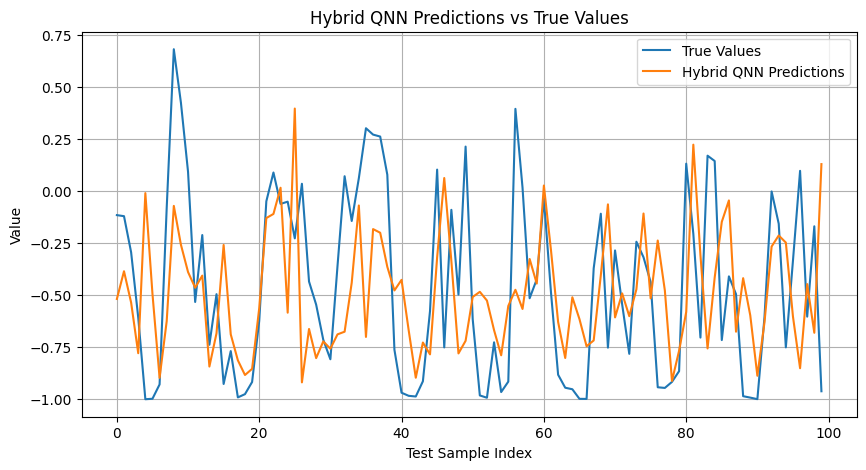

In [26]:
# =========================
# PLOT TRUE VS PREDICTED VALUES
# =========================

import matplotlib.pyplot as plt

y_true_list = y_test_torch.detach().cpu().tolist()
y_pred_list = y_pred_test.detach().cpu().tolist()

plt.figure(figsize=(10, 5))

plt.plot(y_true_list, label="True Values")
plt.plot(y_pred_list, label="Hybrid QNN Predictions")

plt.xlabel("Test Sample Index")
plt.ylabel("Value")
plt.title("Hybrid QNN Predictions vs True Values")
plt.legend()
plt.grid(True)

plt.show()

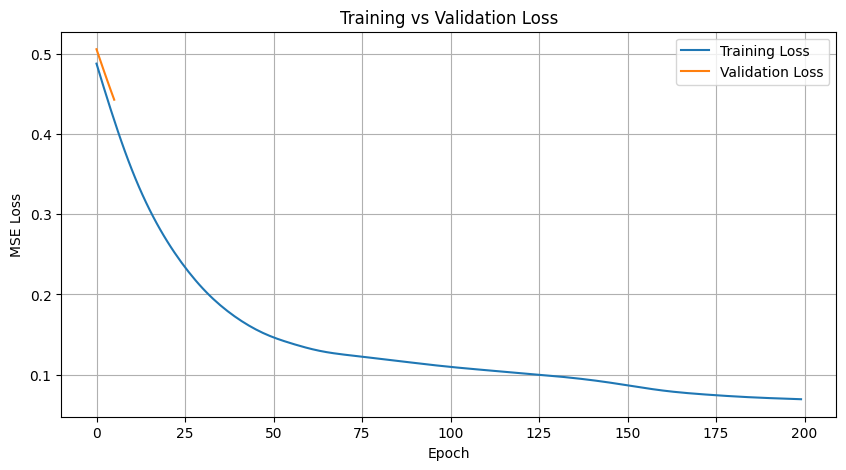

In [25]:
# =========================
# PLOT TRAINING AND VALIDATION LOSS
# =========================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [58]:
params_parallel = 2 * np.pi * np.random.random( size = (n_layers, n_ansatz_layers, n_qubits, 3))
print(params_parallel)

[[[[1.15255478e+00 4.89894304e+00 3.75012014e+00]
   [2.80124980e+00 6.28160922e-01 2.88554589e+00]
   [2.09675304e+00 8.97658691e-01 4.08965289e+00]
   [3.54444404e-01 4.53645208e+00 5.89710059e+00]
   [4.89313009e-03 6.23424909e+00 3.87975075e+00]]]


 [[[3.84313015e+00 4.43989051e-02 1.44905490e-01]
   [3.29725643e+00 2.51240058e+00 2.93209009e-01]
   [6.11828637e+00 1.46254547e+00 5.69297018e-01]
   [3.88543389e+00 2.40307956e+00 6.17782186e+00]
   [2.93275775e+00 5.40316493e+00 4.27449833e+00]]]


 [[[2.83057028e+00 8.33462091e-02 5.92002823e+00]
   [3.53924425e+00 2.42164331e+00 1.00318921e-01]
   [1.45074869e+00 1.51440767e+00 4.29307130e+00]
   [3.83272204e+00 5.23511803e+00 1.08928224e+00]
   [2.45710626e+00 1.14502311e+00 4.74607571e+00]]]


 [[[2.67133314e+00 1.30653600e+00 3.56696636e+00]
   [1.96747219e-01 5.29223132e+00 2.82588856e+00]
   [2.48280216e+00 5.82236937e+00 4.56958472e+00]
   [2.05171616e+00 3.58420520e+00 3.27249817e+00]
   [6.03922194e+00 5.30636267e+00 4.69

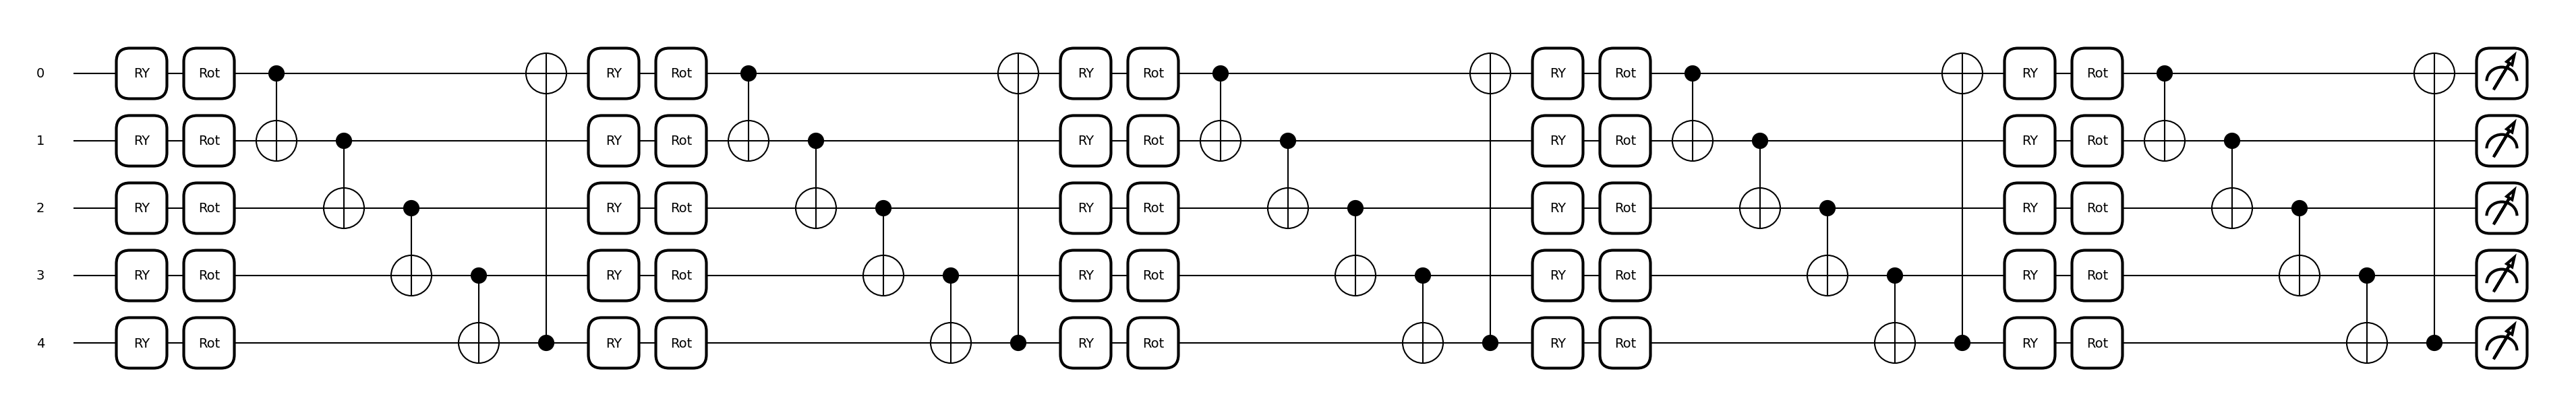

In [26]:
import pennylane as qml
import matplotlib.pyplot as plt
import torch

# Take one input sample
x_sample = X[0]

# Draw quantum circuit using current trained parameters
fig, ax = qml.draw_mpl(circuit_parallel)(
    model.q_params.detach(),
    x_sample
)

plt.show()

In [60]:
np.random.seed(42)

def square_loss(targets, predictions):
    
    loss = 0
    for (t,p) in zip(targets,predictions):
        loss += (t-p)**2

    loss = 0.5 * (loss/len(targets))
    return loss

In [61]:
def cost(params, x , y):
    predictions = [ circuit_parallel(params, x = x_) for x_ in x]
    return square_loss(y, predictions)

In [62]:
file_path = "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"
df = pd.read_csv(file_path)

In [27]:
#df.index = pd.to_datetime


def df_to_X_y(df, window_size = 5):
    df_as_np = df.to_numpy()
    X = []
    y = []
    for i in range(len(df_as_np) - window_size):
        row = [[a] for a in df_as_np[i:i+5]]
        X.append(row)
        label = df_as_np[i+5]
        y.append(label)
    return onp.array(X), onp.array(y)

In [64]:
WS = n_qubits
col_E = df.iloc[:, 4]
X,y = df_to_X_y(col_E, WS)
X.shape, y.shape

((534, 5, 1), (534,))

In [65]:
X_train, y_train = X[:334], y[:334]
X_val, y_val = X[334:434], y[334:434]
X_test, y_test = X[434:], y[434:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((334, 5, 1), (334,), (100, 5, 1), (100,))

In [66]:
#for x_ in X_train:
#    print(x_)

circuit_parallel(params_parallel, X_train[0])

tensor([0.33676652], requires_grad=True)

In [67]:
cst = [cost(params_parallel, X_train, y_train)]
opt = qml.AdamOptimizer(0.3)
n_iter = 200
batch_size = 100


In [68]:
cst

[tensor([5796.91322188], requires_grad=True)]

In [ ]:
for steps in range(n_iter):
    batch_index = np.random.randint(0, len(X_train), (batch_size,))
    x_batch = X_train[batch_index]
    y_batch = y_train[batch_index]

    params_parallel = opt.step(lambda p: cost(p, x_batch, y_batch), params_parallel)

    c = cost(params_parallel, X_train, y_train)
    cst.append(c)
    if ((steps +1) % 10) == 0 :
        print( "Cost at step {0:3}: {1}".format(steps+1, c))
    

Cost at step  10: [5793.22187408]
Cost at step  20: [5792.17458357]
Cost at step  30: [5790.61418147]
Cost at step  40: [5792.38835205]
Cost at step  50: [5794.80518153]
Cost at step  60: [5791.90166563]
Cost at step  70: [5793.01853835]
Cost at step  80: [5792.02525356]
Cost at step  90: [5792.95320597]
Cost at step 100: [5791.89387179]
Cost at step 110: [5790.70252343]
Cost at step 120: [5793.77212267]
Cost at step 130: [5794.08548407]
Cost at step 140: [5791.4350269]
Cost at step 150: [5792.84740829]
Cost at step 160: [5792.72849972]
Cost at step 170: [5792.76453226]
Cost at step 180: [5792.42898208]
Cost at step 190: [5793.7376537]
Cost at step 200: [5793.13428568]
